<!-- CELL 1 — MARKDOWN -->
# Phase 6 — Business Simulation
### Uplift Modeling on the Hillstrom Email Marketing Dataset

**Project:** `uplift-causal-ml` — a 7-phase causal machine learning project on uplift modeling.

**Recap of Phase 5's key finding, carried forward as a hard constraint on this notebook:**
the Two-Model Approach had the highest point-estimate Qini coefficient (0.0234), but
**every model's 95% bootstrap confidence interval included zero and overlapped with every
other model's CI** -- meaning no model, including the naive baseline, can be statistically
proven better than random targeting on this dataset's sample size. **This notebook does
not, and will not, declare a definitive "winner" anywhere.** Every result below is
presented as a point estimate with that caveat attached.

**This notebook (Phase 6) covers:**
1. A business framing: limited budget, which targeting strategy maximizes real incremental
   visits, at 10% and 20% budget levels
2. Simulating 5 strategies (Baseline, Two-Model, Class Transformation, Causal Forest,
   Random Selection) at both budget levels, using real test-set outcomes
3. A summary table and a grouped bar chart comparing estimated total incremental visits
4. An explicit restatement of Phase 5's statistical caveat
5. An honest practical takeaway: what a real deployment would need to gain real certainty


<!-- CELL 2 — MARKDOWN -->
## 1. Load Phase 4 and Phase 5 outputs

In [1]:
# ---------------------------------------------------------------------------
# CELL 3 — CODE: Load the combined rankings (Phase 4) and the Qini results
# with confidence intervals (Phase 5, for reference throughout this
# notebook's commentary).
# ---------------------------------------------------------------------------
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.append(os.path.abspath(os.path.join("..")))

processed_dir = os.path.join("..", "data", "processed")
reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

combined = pd.read_csv(os.path.join(processed_dir, "uplift_scores_combined.csv"))
phase5_results = pd.read_csv(os.path.join(processed_dir, "phase5_results.csv"))

print(f"Loaded {len(combined):,} test customers with 4 rankings")
print("\nPhase 5 Qini results (for reference throughout this notebook):")
display(phase5_results)


Loaded 12,800 test customers with 4 rankings

Phase 5 Qini results (for reference throughout this notebook):


,model,qini_coefficient,ci_lower_95,ci_upper_95,uplift_at_10pct,uplift_at_20pct,uplift_at_30pct
0,"Baseline (naive, non-causal)",0.0129,-0.0134,0.0420,0.0821,0.0836,0.0634
1,Two-Model Approach,0.0234,-0.0041,0.0520,0.0858,0.0754,0.0740
2,Class Transformation,0.0231,-0.0062,0.0507,0.0712,0.0751,0.0654
3,Causal Forest,0.0077,-0.0220,0.0353,0.0476,0.0532,0.0596


<!-- CELL 4 — MARKDOWN -->
## 2. Business scenario

A company running this email campaign has budget to contact only a **limited share** of
its customer base -- not everyone. Given a fixed budget, the practical question isn't
"which model has the best Qini coefficient" in the abstract, it's: **if we can only email
the top X% of customers, which targeting strategy delivers the most real incremental
visits at that budget?**

We simulate this at **two budget levels -- 10% and 20%** of the customer base -- since a
strategy that looks good at one budget might not hold up at another (e.g. a model that
finds a small group of extremely responsive customers may do very well at 10% but add
little extra value by 20%, if the next-best customers it adds are closer to average).


<!-- CELL 5 — MARKDOWN -->
## 3. Simulate all 5 strategies at both budget levels

For each strategy and each budget level, we select the top-K% of customers by that
strategy's ranking (or a random K% sample, for Random Selection -- our control
comparison), then compute the **actual** treated-vs-control visit-rate gap within that
selected group using real test-set outcomes (not predicted scores), and multiply by the
group size to get the estimated total incremental visits under that strategy.


In [2]:
# ---------------------------------------------------------------------------
# CELL 6 — CODE: For each of the 5 strategies and each budget level, select
# the top-K% of customers (or a random K% sample, for Random Selection) via
# src/business_simulation.py's simulate_budget_strategies(), compute the
# ACTUAL treated-vs-control visit-rate gap within that selected group, and
# estimate total incremental visits.
# ---------------------------------------------------------------------------
from src.business_simulation import simulate_budget_strategies

BUDGET_LEVELS = (0.10, 0.20)
RANDOM_SEED = 42  # for reproducible Random Selection sampling, configurable

strategy_columns = {
    "Baseline (naive)": "baseline_predicted_prob",
    "Two-Model": "uplift_two_model",
    "Class Transformation": "uplift_class_transform",
    "Causal Forest": "uplift_causal_forest",
    # "Random Selection" is added automatically inside the module -- no ranking column needed
}

summary_table = simulate_budget_strategies(
    combined, strategy_columns, budget_levels=BUDGET_LEVELS, random_state=RANDOM_SEED,
)

simulation_rows = summary_table.to_dict("records")
print(f"Simulated {len(strategy_columns) + 1} strategies x {len(BUDGET_LEVELS)} budget levels "
      f"= {len(simulation_rows)} rows")


Simulated 5 strategies x 2 budget levels = 10 rows


<!-- CELL 7 — MARKDOWN -->
## 4. Summary table

In [3]:
# ---------------------------------------------------------------------------
# CELL 8 — CODE: Display the summary table (already sorted by budget level,
# then by estimated incremental visits descending, inside the module).
# ---------------------------------------------------------------------------
summary_table_display = summary_table.copy()
summary_table_display["actual_incremental_visit_rate"] = summary_table_display["actual_incremental_visit_rate"].round(4)
summary_table_display["estimated_total_incremental_visits"] = summary_table_display["estimated_total_incremental_visits"].round(1)

display(summary_table_display)


,strategy,budget_level,customers_contacted,actual_incremental_visit_rate,estimated_total_incremental_visits
0,Two-Model,10%,1280,0.0858,109.9
1,Baseline (naive),10%,1280,0.0821,105.0
2,Class Transformation,10%,1280,0.0712,91.1
3,Causal Forest,10%,1280,0.0470,60.2
4,Random Selection,10%,1280,0.0403,51.5
5,Baseline (naive),20%,2560,0.0836,213.9
6,Two-Model,20%,2560,0.0756,193.6
7,Class Transformation,20%,2560,0.0751,192.2
8,Causal Forest,20%,2560,0.0532,136.2
9,Random Selection,20%,2560,0.0458,117.2


<!-- CELL 9 — MARKDOWN -->
## 5. Business impact comparison chart

Saved plot -> ..\reports\business_impact_comparison.png


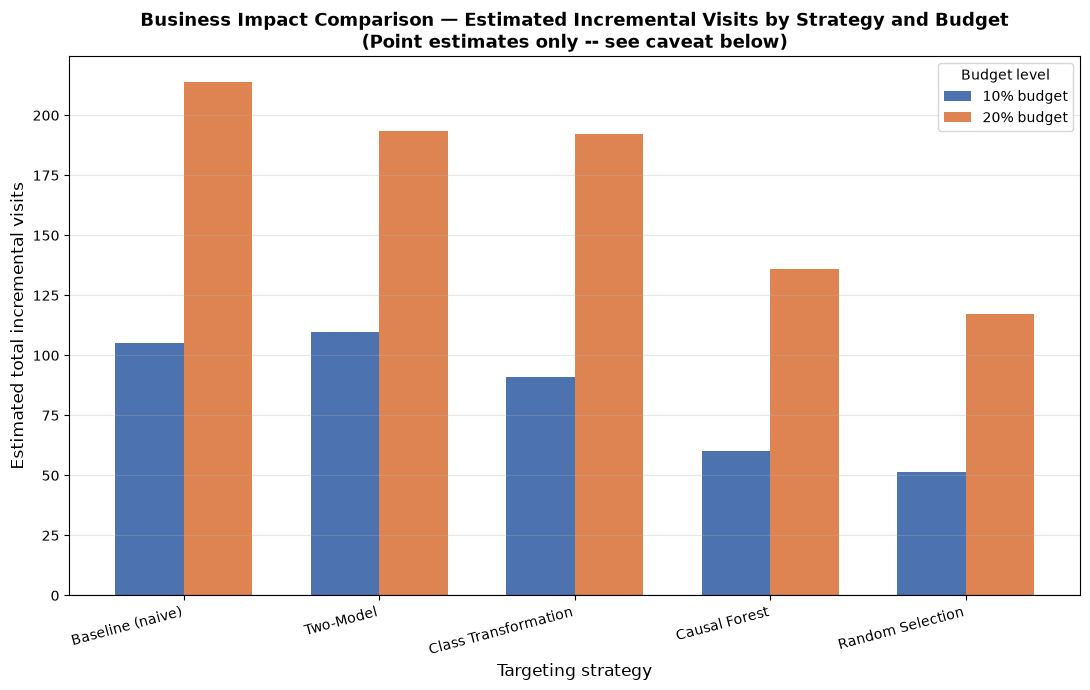

In [4]:
# ---------------------------------------------------------------------------
# CELL 10 — CODE: One grouped bar chart via src/business_simulation.py's
# plot_business_impact() -- x-axis = strategy (including Random), grouped
# bars for 10% and 20% budget levels. Saved to reports/.
# ---------------------------------------------------------------------------
from src.business_simulation import plot_business_impact

strategy_order = ["Baseline (naive)", "Two-Model", "Class Transformation", "Causal Forest", "Random Selection"]
budget_labels = [f"{int(b*100)}%" for b in BUDGET_LEVELS]

plot_path = os.path.join(reports_dir, "business_impact_comparison.png")
fig = plot_business_impact(summary_table, strategy_order, budget_labels, save_path=plot_path)
print(f"Saved plot -> {plot_path}")
plt.show()


<!-- CELL 11 — MARKDOWN -->
## 6. Statistical caveat (restating Phase 5 explicitly)

**The differences shown in the table and chart above are point estimates from a single
test set of 12,800 customers.** Per Phase 5's bootstrap confidence intervals, **none of
these models' Qini coefficients are statistically distinguishable from each other, or from
random targeting, at the 95% confidence level** -- every confidence interval overlapped
with every other model's, and every interval included zero.

That means: the ranking shown above (which strategy has the highest bar at each budget
level) reflects what happened to work best on **this specific test set**, not a
statistically confirmed ordering that we'd expect to hold on a new, independent sample. A
different random split of the same underlying population could plausibly reorder these
bars. **This simulation should be read as "what the point estimates suggest," with the
explicit caveat that this dataset's size cannot statistically confirm these differences are
real** -- not as proof that any targeting strategy is genuinely superior to another.


<!-- CELL 12 — MARKDOWN -->
## 7. Practical takeaway

In [5]:
# ---------------------------------------------------------------------------
# CELL 13 — CODE: Compute whether every non-random strategy beat Random
# Selection, at both budget levels, via src/business_simulation.py's
# check_beat_random() -- the one pattern in this simulation that IS worth
# stating plainly, since it holds consistently even though individual
# model rankings don't.
# ---------------------------------------------------------------------------
from src.business_simulation import check_beat_random

beat_random_df, all_beat_random = check_beat_random(summary_table, strategy_order, budget_labels)

print("Did each non-random strategy beat Random Selection in point estimates?")
display(beat_random_df)
print(f"\nAll strategies beat Random Selection at every budget level (point estimates): {all_beat_random}")


Did each non-random strategy beat Random Selection in point estimates?


,budget_level,strategy,beat_random_in_point_estimate
0,10%,Baseline (naive),True
1,10%,Two-Model,True
2,10%,Class Transformation,True
3,10%,Causal Forest,True
4,20%,Baseline (naive),True
5,20%,Two-Model,True
6,20%,Class Transformation,True
7,20%,Causal Forest,True



All strategies beat Random Selection at every budget level (point estimates): True


In [6]:
# ---------------------------------------------------------------------------
# CELL 14 — CODE: Assemble the practical takeaway markdown from the actual
# computed pattern above, so it reflects the real run rather than an
# assumed outcome.
# ---------------------------------------------------------------------------
takeaway_md = f"""
### Practical Takeaway

**What we can say, honestly:** in this simulation's point estimates, {"every targeting strategy (including the naive, non-causal baseline) outperformed Random Selection at both the 10% and 20% budget levels" if all_beat_random else "most, but not all, targeting strategies outperformed Random Selection across the two budget levels (see the table above for exceptions)"}.
This is a **more modest, but still meaningful and defensible finding** than claiming "our
uplift model is best" -- it suggests that *some* form of predictive targeting (even a
simple one) likely beats spending the same budget on randomly chosen customers, even
though we cannot statistically confirm *which specific model* is the best choice among the
targeted strategies themselves.

**What a real deployment would need to gain actual statistical certainty:**

- **A much larger dataset.** Phase 5's confidence intervals were wide primarily because of
  sample size (12,800 test customers, with visit and especially conversion being
  relatively rare events). Diemert, E., Betlei, A., Renaudin, C., & Amini, M. R. (2018).
  *A Large Scale Benchmark for Uplift Modeling*, in their AdKDD & TargetAd workshop paper,
  used the Criteo uplift dataset with **over 25 million rows** specifically because
  distinguishing uplift models statistically requires that scale -- our ~64,000-row
  Hillstrom dataset is orders of magnitude smaller than what that benchmark used to draw
  confident conclusions between methods.
- **A longer or repeated experiment**, to accumulate more outcome events (visits,
  conversions) rather than relying on a single train/test split.
- **Pre-registered evaluation on a held-out, never-touched validation set**, to avoid any
  risk of the modeling choices in Phases 3-5 having been implicitly tuned toward this
  particular test set.

**Bottom line:** this project demonstrates the full uplift modeling pipeline correctly --
data validation, preprocessing, three legitimate uplift modeling approaches, and rigorous
statistical evaluation -- and its honest conclusion is that **on this dataset's size, no
single method's superiority over the others (or over random targeting, in the strict
statistical sense) can be confirmed.** That is a valid and useful research finding in its
own right, not a shortcoming of the analysis.
"""

display(Markdown(takeaway_md))



### Practical Takeaway

**What we can say, honestly:** in this simulation's point estimates, every targeting strategy (including the naive, non-causal baseline) outperformed Random Selection at both the 10% and 20% budget levels.
This is a **more modest, but still meaningful and defensible finding** than claiming "our
uplift model is best" -- it suggests that *some* form of predictive targeting (even a
simple one) likely beats spending the same budget on randomly chosen customers, even
though we cannot statistically confirm *which specific model* is the best choice among the
targeted strategies themselves.

**What a real deployment would need to gain actual statistical certainty:**

- **A much larger dataset.** Phase 5's confidence intervals were wide primarily because of
  sample size (12,800 test customers, with visit and especially conversion being
  relatively rare events). Diemert, E., Betlei, A., Renaudin, C., & Amini, M. R. (2018).
  *A Large Scale Benchmark for Uplift Modeling*, in their AdKDD & TargetAd workshop paper,
  used the Criteo uplift dataset with **over 25 million rows** specifically because
  distinguishing uplift models statistically requires that scale -- our ~64,000-row
  Hillstrom dataset is orders of magnitude smaller than what that benchmark used to draw
  confident conclusions between methods.
- **A longer or repeated experiment**, to accumulate more outcome events (visits,
  conversions) rather than relying on a single train/test split.
- **Pre-registered evaluation on a held-out, never-touched validation set**, to avoid any
  risk of the modeling choices in Phases 3-5 having been implicitly tuned toward this
  particular test set.

**Bottom line:** this project demonstrates the full uplift modeling pipeline correctly --
data validation, preprocessing, three legitimate uplift modeling approaches, and rigorous
statistical evaluation -- and its honest conclusion is that **on this dataset's size, no
single method's superiority over the others (or over random targeting, in the strict
statistical sense) can be confirmed.** That is a valid and useful research finding in its
own right, not a shortcoming of the analysis.


<!-- CELL 15 — MARKDOWN -->
## 8. Save the summary table

In [7]:
# ---------------------------------------------------------------------------
# CELL 16 — CODE: Save the full summary table to
# data/processed/phase6_business_impact.csv.
# ---------------------------------------------------------------------------
output_path = os.path.join(processed_dir, "phase6_business_impact.csv")
summary_table.to_csv(output_path, index=False)

print(f"Saved business impact summary table -> {output_path}")
print(f"Saved comparison plot                -> {os.path.join(reports_dir, 'business_impact_comparison.png')}")


Saved business impact summary table -> ..\data\processed\phase6_business_impact.csv
Saved comparison plot                -> ..\reports\business_impact_comparison.png
